# Applications of Diffusion Models: Personalization

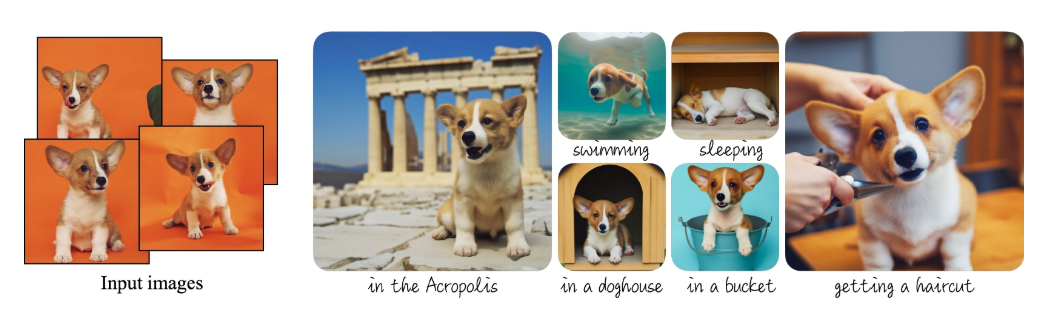

Diffusion personalization is a method for teaching a pre-trained text-to-image diffusion model to reproduce a specific, user-defined concept using only a few example images. Rather than updating all model parameters, this approach adds a single placeholder token (e.g. `<target_concept>`) to the tokenizer and optimizes only its embedding, while the U-Net, VAE, and text encoder remain frozen. During training, a small set of representative images (typically 3–5) is paired with prompts containing `<target_concept>`, and the embedding is adjusted so that the model learns the visual patterns of the target concept.

Once training is complete, the learned token can be used in any prompt—such as “a photo of a `<target_concept>` in a modern gallery”—and the model will generate faithful renditions of the specific concept in novel settings.

- Key Application Areas

  - E-commerce product imaging
Generate consistent, high-quality views of a new item from arbitrary angles and backgrounds, based on only a handful of photographs.

  - Industrial design prototyping
Visualize custom parts or color variants instantly, facilitating rapid iteration and client feedback.

  - Medical image augmentation
Produce synthetic scans that emphasize particular lesions or anomalies using limited patient data, aiding both research and educational tasks.

  - Cultural heritage reconstruction
Recreate the original appearance of damaged artifacts by learning their textures and forms from surviving images.

This lightweight fine-tuning strategy preserves the model’s general generative knowledge while enabling precise control over novel, user-specified concepts.

# Textual Inversion

Title: An Image is Worth One Word: Personalizing Text-to-Image Generation using Textual Inversion

https://arxiv.org/pdf/2208.01618

## Understanding Textual Inversion

**Textual Inversion** is a lightweight technique for teaching a pre-trained text-to-image diffusion model a new visual concept using only a few reference images. Instead of fine-tuning the entire model, the method introduces a new "placeholder token" (e.g., `*S`) that stands in for the target concept in prompts. By pairing each reference image with a prompt like "a photo of `*S`," the training process learns a unique embedding for this token. During training, all other components of the model—including the UNet, VAE, and most of the text encoder—remain frozen. Only the embedding for the new token is updated to capture the visual characteristics of the provided examples. This allows the model to generate novel images of the learned concept while preserving its original capabilities.


## Structural Overview of Textual Inversion
To understand how Textual Inversion works structurally, we can break it down into key components and the general process flow:

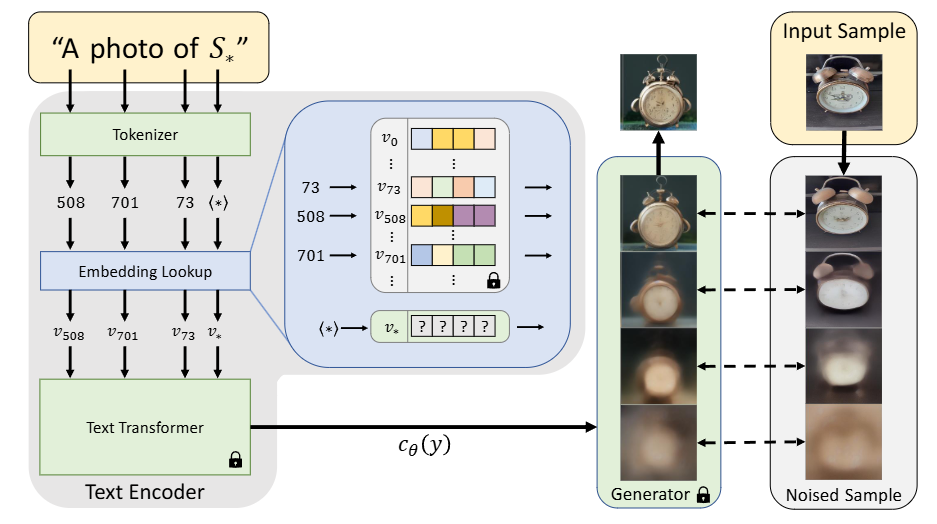


### 1. Core Components

- Pre-trained Diffusion Model: We start with an existing, powerful text-to-image model. This model already has its main parts:
 - **Tokenizer**: Breaks down input text prompts into tokens.
 - **Text Encoder**: Converts these tokens into text `embeddings` that the model can understand. This is where our new `placeholder_token`'s `embedding` will live and be modified.
 - **VAE (Variational Autoencoder)**: Encodes images into a compact latent representation and decodes these latents back into images.
 - **UNet**: The core of the image generation process; it learns to denoise latents based on the text `embeddings`.

- Our Custom Concept: This is represented by a small set of images (e.g., 3-5 images of the object or style we want to teach).
- `placeholder_token`: A new, unique "word" (e.g., `<backpack_dog>`) that we define to represent our custom concept.
- `initializer_token`: An existing word in the model's vocabulary (e.g., "`backpack`") whose `embedding` is used as a starting point for our `placeholder_token`'s `embedding`. This helps the training process.
- The Target:
  - A Learned `Embedding`: The primary goal is to learn a specific numerical vector (the `embedding`) for our `placeholder_token`. This `embedding`, when fed into the text encoder, will guide the **UNet** to generate images of our custom concept.


### 2. The Process Flow

- **Initialization:**
 - The new `placeholder_token` is added to the Tokenizer's vocabulary.
 - The Text Encoder's `embedding` layer is expanded to include this new token.
 - The initial `embedding` for our `placeholder_token` is set to be the same as the `embedding` of the chosen initializer_token.

- **Selective Training Setup:**
 - Crucially, all parts of the pre-trained diffusion model (the VAE, the UNet, and the Text Encoder except for our new token's `embedding`) are "frozen." This means their weights will not change during training.
 - The only trainable parameter in this setup is the `embedding` vector corresponding to our `placeholder_token`.

- **Training Loop:**
 - The model is shown our custom images one by one (or in small batches), paired with text prompts that include our `placeholder_token` (e.g., "a photo of <my_cat_fluffy>").
 - For each image and prompt pair:
   1. The image is encoded into a latent representation by the VAE.
   2. Noise is added to this latent (simulating a step in the diffusion process).
   3. The Text Encoder processes the prompt, using the current (possibly partially learned) `embedding` for our `placeholder_token`.
   4. The UNet attempts to predict and remove the noise from the noisy latent, guided by the text `embedding`.
   5. A "loss" is calculated, measuring how different the UNet's prediction is from the actual noise that was added.
   6. This loss is then used to update only the `embedding` of our `placeholder_token`, trying to make the UNet's prediction better for the next iteration.

- **Outcome:**
 - After sufficient training steps, the `embedding` for our `placeholder_token` becomes finely tuned to represent our specific visual concept.
 - This learned `embedding` (often just a small file) can then be used with the original pre-trained model to generate new images featuring our custom concept, just by using the `placeholder_token` in prompts.

# 0 - Prepare


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
#@title Install the required libs
!pip install -U -qq git+https://github.com/huggingface/diffusers.git
!pip install -qq accelerate transformers ftfy

In [ ]:
#@title Import required libraries
import argparse
import itertools
import math
import os
import random


import numpy as np
import torch
import torch.nn.functional as F
import torch.utils.checkpoint
from torch.utils.data import Dataset
from transformers import CLIPTextModel, CLIPProcessor, CLIPModel
from pathlib import Path
from PIL import Image

import PIL
from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import set_seed
from diffusers import AutoencoderKL, DDPMScheduler, PNDMScheduler, StableDiffusionPipeline, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from diffusers.pipelines.stable_diffusion import StableDiffusionSafetyChecker
from diffusers import DPMSolverMultistepScheduler
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm
from transformers import CLIPFeatureExtractor, CLIPTextModel, CLIPTokenizer

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

# 1 - Learning the New Token

In [ ]:
#@title Setting pre-trained model
pretrained_model_name_or_path = "stable-diffusion-v1-5/stable-diffusion-v1-5"

In [ ]:
#@title Configure subject information
#################################################
# Prepare 4 to 6 images for fine-tuning and place them in images_path.
# Set the placeholder_token and the initializer_token to initialize it.

# Modify this section of the code as needed
images_path = "cat2"
placeholder_token = "<cat2>"
initializer_token = "cat"
what_to_teach = "object"

#################################################

while not os.path.exists(str(images_path)):
    print('The images_path specified does not exist, use the colab file explorer to copy the path :')
    images_path=input("")
save_path = images_path

In [ ]:
# Visualization
images = []
for file_path in os.listdir(save_path):
    try:
        image_path = os.path.join(save_path, file_path)
        images.append(Image.open(image_path).resize((512, 512)))
    except:
      print(f"{image_path} is not a valid image, please make sure to remove this file from the directory otherwise the training could fail.")
image_grid(images, 1, len(images))


In [ ]:
#@title Setup the prompt templates for training
imagenet_templates_small = [
    "a photo of a {}",
    "a rendering of a {}",
    "a cropped photo of the {}",
    "the photo of a {}",
    "a photo of a clean {}",
    "a photo of a dirty {}",
    "a dark photo of the {}",
    "a photo of my {}",
    "a photo of the cool {}",
    "a close-up photo of a {}",
    "a bright photo of the {}",
    "a cropped photo of a {}",
    "a photo of the {}",
    "a good photo of the {}",
    "a photo of one {}",
    "a close-up photo of the {}",
    "a rendition of the {}",
    "a photo of the clean {}",
    "a rendition of a {}",
    "a photo of a nice {}",
    "a good photo of a {}",
    "a photo of the nice {}",
    "a photo of the small {}",
    "a photo of the weird {}",
    "a photo of the large {}",
    "a photo of a cool {}",
    "a photo of a small {}",
]

imagenet_style_templates_small = [
    "a painting in the style of {}",
    "a rendering in the style of {}",
    "a cropped painting in the style of {}",
    "the painting in the style of {}",
    "a clean painting in the style of {}",
    "a dirty painting in the style of {}",
    "a dark painting in the style of {}",
    "a picture in the style of {}",
    "a cool painting in the style of {}",
    "a close-up painting in the style of {}",
    "a bright painting in the style of {}",
    "a cropped painting in the style of {}",
    "a good painting in the style of {}",
    "a close-up painting in the style of {}",
    "a rendition in the style of {}",
    "a nice painting in the style of {}",
    "a small painting in the style of {}",
    "a weird painting in the style of {}",
    "a large painting in the style of {}",
]

In [ ]:
#@title Setup the dataset
class TextualInversionDataset(Dataset):
    def __init__(
        self,
        data_root,
        tokenizer,
        learnable_property="object",  # [object, style]
        size=512,
        repeats=100,
        interpolation="bicubic",
        flip_p=0.5,
        set="train",
        placeholder_token="*",
        center_crop=False,
    ):

        self.data_root = data_root
        self.tokenizer = tokenizer
        self.learnable_property = learnable_property
        self.size = size
        self.placeholder_token = placeholder_token
        self.center_crop = center_crop
        self.flip_p = flip_p

        self.image_paths = [os.path.join(self.data_root, file_path) for file_path in os.listdir(self.data_root)]

        self.num_images = len(self.image_paths)
        self._length = self.num_images

        if set == "train":
            self._length = self.num_images * repeats

        self.interpolation = {
            "bilinear": PIL.Image.BILINEAR,
            "bicubic": PIL.Image.BICUBIC,
            "lanczos": PIL.Image.LANCZOS,
        }[interpolation]

        self.templates = imagenet_style_templates_small if learnable_property == "style" else imagenet_templates_small
        self.flip_transform = transforms.RandomHorizontalFlip(p=self.flip_p)

    def __len__(self):
        return self._length

    def __getitem__(self, i):
        example = {}

        image = Image.open(self.image_paths[i % self.num_images])
        if not image.mode == "RGB":
            image = image.convert("RGB")

        image = Image.fromarray(np.array(image).astype(np.uint8))
        image = image.resize((self.size, self.size), resample=self.interpolation)

        image = self.flip_transform(image)
        image = np.array(image).astype(np.uint8)
        image = (image / 127.5 - 1.0).astype(np.float32)

        example["pixel_values"] = torch.from_numpy(image).permute(2, 0, 1)

        placeholder_string = self.placeholder_token
        text = random.choice(self.templates).format(placeholder_string)

        example["input_ids"] = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        ).input_ids[0]

        return example


In [ ]:
#@title Setup the tokenizer & handle the initializer token
# Load the tokenizer and add the placeholder token as a additional special token.
tokenizer = CLIPTokenizer.from_pretrained(
    pretrained_model_name_or_path,
    subfolder="tokenizer",
)

#################################################
# TODO: Add the placeholder token in tokenizer.
#################################################
# [START]
num_added_tokens = None

if num_added_tokens == 0:
    raise ValueError(
        f"The tokenizer already contains the token {placeholder_token}. Please pass a different"
        " `placeholder_token` that is not already in the tokenizer."
    )
# [END]


#################################################
# TODO: Convert the initializer_token, placeholder_token to ids.
#################################################
# [START]

token_ids = None

# [END]


# Check if initializer_token is a single token or a sequence of tokens
if len(token_ids) > 1:
    raise ValueError("The initializer token must be a single token.")

initializer_token_id = token_ids[0]
placeholder_token_id = tokenizer.convert_tokens_to_ids(placeholder_token)

In [ ]:
#@title Load the Stable Diffusion model
text_encoder = CLIPTextModel.from_pretrained(
    pretrained_model_name_or_path, subfolder="text_encoder"
)
vae = AutoencoderKL.from_pretrained(
    pretrained_model_name_or_path, subfolder="vae"
)
unet = UNet2DConditionModel.from_pretrained(
    pretrained_model_name_or_path, subfolder="unet"
)

In [ ]:
text_encoder.resize_token_embeddings(len(tokenizer))

In [ ]:
# Initialize the placeholder token embedding by copying the initializer token embedding
token_embeds = text_encoder.get_input_embeddings().weight.data
token_embeds[placeholder_token_id] = token_embeds[initializer_token_id]

In [ ]:
#@title Freeze the model
#################################################
# TODO: Freeze the model to train only the embeddings.
#################################################
# [START]
def freeze_params(params):
    pass

# Freeze vae and unet
pass

# Freeze all parameters except for the token embeddings in text encoder
pass

# [END]

In [ ]:
#@title prepare training dataset
train_dataset = TextualInversionDataset(
      data_root=save_path,
      tokenizer=tokenizer,
      size=vae.sample_size,
      placeholder_token=placeholder_token,
      repeats=100,
      learnable_property=what_to_teach,
      center_crop=False,
      set="train",
)

In [ ]:
#@title Create DataLoader and Initialize DDPMScheduler

def create_dataloader(train_batch_size=1):
    return torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)

noise_scheduler = DDPMScheduler.from_config(pretrained_model_name_or_path, subfolder="scheduler")

In [ ]:
#@title Setting up all training hyperparameters
hyperparameters = {
    "learning_rate": 5e-04,
    "scale_lr": True,
    "max_train_steps": 1000,
    "save_steps": 100,
    "train_batch_size": 4,
    "gradient_accumulation_steps": 1,
    "gradient_checkpointing": True,
    "mixed_precision": "fp16",
    "seed": 42,
    "output_dir": "sd-concept-output"
}
!mkdir -p sd-concept-output

In [ ]:
#@title Define training loop
logger = get_logger(__name__)

def save_progress(text_encoder, placeholder_token_id, accelerator, save_path):
    logger.info("Saving embeddings")
    learned_embeds = accelerator.unwrap_model(text_encoder).get_input_embeddings().weight[placeholder_token_id]
    learned_embeds_dict = {placeholder_token: learned_embeds.detach().cpu()}
    torch.save(learned_embeds_dict, save_path)

def training_function(text_encoder, vae, unet):
    train_batch_size = hyperparameters["train_batch_size"]
    gradient_accumulation_steps = hyperparameters["gradient_accumulation_steps"]
    learning_rate = hyperparameters["learning_rate"]
    max_train_steps = hyperparameters["max_train_steps"]
    output_dir = hyperparameters["output_dir"]
    gradient_checkpointing = hyperparameters["gradient_checkpointing"]

    accelerator = Accelerator(
        gradient_accumulation_steps=gradient_accumulation_steps,
        mixed_precision=hyperparameters["mixed_precision"]
    )

    if gradient_checkpointing:
        text_encoder.gradient_checkpointing_enable()
        unet.enable_gradient_checkpointing()

    train_dataloader = create_dataloader(train_batch_size)

    if hyperparameters["scale_lr"]:
        learning_rate = (
            learning_rate * gradient_accumulation_steps * train_batch_size * accelerator.num_processes
        )

    #################################################
    # TODO: determine which parameters to pass to the optimizer.
    # Hint: explore the text_encoder object to find its attributes or methods:
    #   print(dir(text_encoder))
    #   help(text_encoder)
    # Then call .parameters() on the appropriate one.
    #################################################
    # [START]
    optimizer = torch.optim.AdamW(
        None,                                 # e.g. text_encoder.<your_choice>.parameters()
        lr=learning_rate,
    )
    # [END]

    viz_dir = os.path.join(output_dir, "viz")
    os.makedirs(viz_dir, exist_ok=True)

    def make_grid(imgs, rows, cols):
        w, h = imgs[0].size
        grid = Image.new('RGB', (cols*w, rows*h))
        for idx, img in enumerate(imgs):
            r, c = divmod(idx, cols)
            grid.paste(img, (c*w, r*h))
        return grid

    text_encoder, optimizer, train_dataloader = accelerator.prepare(
        text_encoder, optimizer, train_dataloader
    )

    weight_dtype = torch.float32
    if accelerator.mixed_precision == "fp16":
        weight_dtype = torch.float16
    elif accelerator.mixed_precision == "bf16":
        weight_dtype = torch.bfloat16

    # Move vae and unet to device
    vae.to(accelerator.device, dtype=weight_dtype)
    unet.to(accelerator.device, dtype=weight_dtype)

    vae.eval()
    unet.train()

    # We need to recalculate our total training steps as the size of the training dataloader may have changed.
    num_update_steps_per_epoch = math.ceil(len(train_dataloader) / gradient_accumulation_steps)
    num_train_epochs = math.ceil(max_train_steps / num_update_steps_per_epoch)

    # Train!
    total_batch_size = train_batch_size * accelerator.num_processes * gradient_accumulation_steps

    logger.info("***** Running training *****")
    logger.info(f"  Num examples = {len(train_dataset)}")
    logger.info(f"  Instantaneous batch size per device = {train_batch_size}")
    logger.info(f"  Total train batch size (w. parallel, distributed & accumulation) = {total_batch_size}")
    logger.info(f"  Gradient Accumulation steps = {gradient_accumulation_steps}")
    logger.info(f"  Total optimization steps = {max_train_steps}")
    # Only show the progress bar once on each machine.
    progress_bar = tqdm(range(max_train_steps), disable=not accelerator.is_local_main_process)
    progress_bar.set_description("Steps")
    global_step = 0

    for epoch in range(num_train_epochs):
        text_encoder.train()
        for step, batch in enumerate(train_dataloader):
            with accelerator.accumulate(text_encoder):
                #################################################
                # TODO: Forward Diffusion Process (Lecture 12 - Generative Model Part4, p18, 19)
                # Hint: Explore the `noise_scheduler` and related pipeline methods yourself:
                #   - print(dir(noise_scheduler))
                #   - help(noise_scheduler.add_noise)
                #   - or:
                #       import inspect
                #       inspect.getfullargspec(noise_scheduler.add_noise)
                # Use these tools to find out how to:
                #   1) sample random timesteps
                #   2) generate noise matching `latents` shape
                #   3) call `add_noise(latents, noise, timesteps)`
                # then assign each to `timesteps`, `noise`, and `noisy_latents` before scaling.
                #################################################
                # [START]

                latents = None
                latents = latents * 0.18215

                noise = None
                bsz = None
                timesteps = None
                noisy_latents = None

                # [END]

                #################################################
                # TODO: Reverse Diffusion Process (Lecture 12 - Generative Model Part4, p25, 26)
                # Pass the token through the text encoder and predict the noise.
                # Hint: Explore the `unet` object yourself:
                #   - print(dir(unet))
                #   - help(unet.forward)
                #   - or:
                #       import inspect
                #       inspect.getfullargspec(unet.forward)
                # Use these tools to discover which arguments `unet.forward` expects and implement accordingly.
                #################################################
                # [START]

                encoder_hidden_states = None
                noise_pred = unet(..., ..., ...).sample

                # [END]

                if noise_scheduler.config.prediction_type == "epsilon":
                    target = noise
                elif noise_scheduler.config.prediction_type == "v_prediction":
                    target = noise_scheduler.get_velocity(latents, noise, timesteps)
                else:
                    raise ValueError(f"Unknown prediction type {noise_scheduler.config.prediction_type}")

                #################################################
                # TODO: Compute the MSE loss.
                #################################################
                # [START]

                loss = None

                # [END]

                accelerator.backward(loss)
                if accelerator.num_processes > 1:
                    grads = text_encoder.module.get_input_embeddings().weight.grad
                else:
                    grads = text_encoder.get_input_embeddings().weight.grad
                index_grads_to_zero = torch.arange(len(tokenizer)) != placeholder_token_id
                grads.data[index_grads_to_zero, :] = grads.data[index_grads_to_zero, :].fill_(0)

                optimizer.step()
                optimizer.zero_grad()

            # Checks if the accelerator has performed an optimization step behind the scenes
            if accelerator.sync_gradients:
                progress_bar.update(1)
                global_step += 1
                if global_step % hyperparameters["save_steps"] == 0:
                    save_path = os.path.join(output_dir, f"learned_embeds-step-{global_step}.bin")
                    save_progress(text_encoder, placeholder_token_id, accelerator, save_path)

            logs = {"loss": loss.detach().item()}
            progress_bar.set_postfix(**logs)

            if global_step >= max_train_steps:
                break
        accelerator.wait_for_everyone()

    if accelerator.is_main_process:
        pipeline = StableDiffusionPipeline.from_pretrained(
            pretrained_model_name_or_path,
            text_encoder=accelerator.unwrap_model(text_encoder),
            tokenizer=tokenizer,
            vae=vae,
            unet=unet,
        )
        pipeline.save_pretrained(output_dir)
        save_path = os.path.join(output_dir, f"learned_embeds.bin")
        save_progress(text_encoder, placeholder_token_id, accelerator, save_path)

# 2 - Use & Evaluate

In [ ]:
#@title Start Training Loop
import accelerate
accelerate.notebook_launcher(training_function, args=(text_encoder, vae, unet), num_processes=1)

for param in itertools.chain(unet.parameters(), text_encoder.parameters()):
  if param.grad is not None:
    del param.grad
  torch.cuda.empty_cache()

In [ ]:
#@title Run Inference & Save Samples
#################################################
# Modify this section of the code as needed.

learned_embeds_step = 1000
prompt = "a photo of a <cat2> in the desert"
num_samples = 5
num_rows = 1

#################################################
pipe = StableDiffusionPipeline.from_pretrained(
    hyperparameters["output_dir"],
    scheduler=DPMSolverMultistepScheduler.from_pretrained(hyperparameters["output_dir"], subfolder="scheduler"),
    torch_dtype=torch.float16,
).to("cuda")

pipe.unload_textual_inversion(tokens="<cat2>")
embed_path = f"{hyperparameters['output_dir']}/learned_embeds-step-{learned_embeds_step}.bin"
pipe.load_textual_inversion(embed_path)

base_name = prompt.replace(" ", "_").replace("<", "").replace(">", "")

output_dir = Path("output_images")
output_dir.mkdir(exist_ok=True)

all_images = []
for row in range(num_rows):
    images = pipe([prompt] * num_samples, num_inference_steps=30, guidance_scale=7.5).images

    for i, img in enumerate(images):
        img.save(output_dir / f"{base_name}_step{learned_embeds_step}_{row * num_samples + i}.png")
    all_images.extend(images)

grid = image_grid(all_images, num_rows, num_samples)
grid


In [ ]:
#@title Observe the denoising process
pipe = StableDiffusionPipeline.from_pretrained(
    hyperparameters["output_dir"],
    scheduler=DPMSolverMultistepScheduler.from_pretrained(
        hyperparameters["output_dir"], subfolder="scheduler"
    ),
    torch_dtype=torch.float16,
).to("cuda")

#################################################
# Modify this section of the code as needed.

learned_embeds_step = 1000
prompt = "a photo of a <cat2> on a cobblestone street"
pipe.unload_textual_inversion(tokens="<cat2>")

#################################################

embed_path = f"{hyperparameters['output_dir']}/learned_embeds-step-{learned_embeds_step}.bin"
pipe.load_textual_inversion(embed_path)

num_samples = 1
num_inference_steps = 30
num_intermediate = 15
target_steps = set(np.linspace(0, num_inference_steps - 1, num_intermediate, dtype=int))

intermediates = []

def save_intermediate(step: int, timestep: int, latents: torch.FloatTensor):
    #################################################
    # TODO
    # Implement the save_intermediate function.
    # Every step you want to save, decodes latents into an image.
    # Add to the list of intermediates.
    #################################################
    # [START]
    if step in target_steps:
        latents_scaled = None

        with torch.no_grad():
            image_tensor = None

        image = None
        pil_images = None

        intermediates.append(pil_images[0])

    # [END]

_ = pipe(
    [prompt] * num_samples,
    num_inference_steps=num_inference_steps,
    guidance_scale=7.5,
    callback=save_intermediate,
    callback_steps=1,
)

def image_grid(images: list[Image.Image], rows: int, cols: int) -> Image.Image:
    w, h = images[0].size
    grid = Image.new('RGB', (cols * w, rows * h))
    for idx, img in enumerate(images):
        row = idx // cols
        col = idx % cols
        grid.paste(img, (col * w, row * h))
    return grid

grid = image_grid(intermediates, rows=1, cols=num_intermediate)
grid


## Quantitative Metric: CLIP Score

- **Evaluation Metrics: CLIP-I and CLIP-T**
  
  In the domain of diffusion-based personalization, evaluating the quality of generated images involves more than just assessing visual appeal. It requires metrics that can rigorously capture both semantic alignment with textual prompts and visual fidelity to reference concepts. Two widely adopted metrics in this context are CLIP-T and CLIP-I, both derived from the CLIP (Contrastive Language–Image Pre-training) model.

- **CLIP-T (CLIP Text-Image Similarity)**
  - **Purpose**: CLIP-T measures how well the generated image reflects the semantics of the input text prompt.

  - **Method**: The CLIP model encodes both the generated image and the prompt into a shared embedding space. The cosine similarity between these embeddings serves as the CLIP-T score. A higher score indicates stronger semantic consistency between text and image.

  - **Relevance**: In personalization settings—such as Textual Inversion or DreamBooth—this metric helps determine whether the model has successfully internalized the learned concept and can express it accurately in response to natural language prompts.

- **CLIP-I (CLIP Image-Image Similarity)**
  - **Purpose**: CLIP-I assesses the degree of visual similarity between the generated image and a ground-truth or reference image.

  - **Method**: Both images are embedded using CLIP’s vision encoder, and their cosine similarity is computed. A higher score suggests greater visual alignment.

  - **Relevance**: This metric is particularly useful for evaluating how faithfully a model reproduces a personalized concept—especially when that concept was introduced using only a few example images. CLIP-I provides a principled way to quantify how well the appearance of the concept is preserved in the generated outputs.


  Taken together, CLIP-T and CLIP-I offer a complementary evaluation framework: the former emphasizes semantic correctness, while the latter focuses on visual accuracy. Their use has become standard practice in evaluating diffusion personalization techniques, particularly in low-shot or concept-driven generation scenarios.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def compute_clip_scores(gen_path: str, gt_path: str, prompt: str):
    def embed(path: str):
        img = Image.open(path).convert("RGB")
        inputs = processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            feats = clip_model.get_image_features(**inputs)
        return F.normalize(feats, dim=-1)

    gen_embed = embed(str(gen_path))
    gt_embed = embed(str(gt_path))

    text_inputs = processor(text=prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        text_embed = clip_model.get_text_features(
            **{k: v for k, v in text_inputs.items() if k.startswith("input")}
        )
    text_embed = F.normalize(text_embed, dim=-1)

    sim_img = (gen_embed * gt_embed).sum(dim=-1).item()
    sim_text = (gen_embed * text_embed).sum(dim=-1).item()

    print(f"CLIP-I: {sim_img:.4f} | CLIP-T: {sim_text:.4f}")
    return sim_img, sim_text

#################################################
# Modify this section of the code as needed
_, _ =compute_clip_scores(
    gen_path=Path("output_images/a_photo_of_a_cat2_on_a_cobblestone_street_step1000_0.png"),
    gt_path=Path("cat2/00.jpg"),
    prompt="a photo of a <cat2> on a cobblestone street"
)
#################################################

# 3 - Additional Experiments
- Conduct an in-depth analysis of when the model succeeds and when it fails under the conditions described above, and document your findings.  
- Propose concrete strategies for advancing the model—covering data, training procedures, loss functions, etc.  
- Based on your proposals, freely design and implement experimental code, and include both the code and its results in your report.  
- You may freely extend or expand the provided code blocks as needed to carry out your experiments.|



- **Optional Suggestions**
  - Although not strictly required, you may extract and inspect the U-Net’s internal cross-attention maps for each prompt token during both training and inference.

  - Additionally, you can observe how the generated visuals evolve across successive training steps to gain deeper insights.

In [ ]:
#################################################
# TODO
# Implement code to run additional experiments that analyze model success/failure under the given conditions,
# apply proposed improvements (data, training procedures, loss functions), and record the results.
#################################################
# [START]




# [END]